# BAD WAY TO USE DATA SCIENCE FOR ANALYZE DATA

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


## Let's Explore the data

In [ ]:
df = pd.read_csv("/content/mental_health_analysis.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   User_ID                5000 non-null   int64  
 1   Age                    5000 non-null   int64  
 2   Gender                 5000 non-null   object 
 3   Social_Media_Hours     5000 non-null   float64
 4   Exercise_Hours         5000 non-null   float64
 5   Sleep_Hours            5000 non-null   float64
 6   Screen_Time_Hours      5000 non-null   float64
 7   Survey_Stress_Score    5000 non-null   int64  
 8   Wearable_Stress_Score  5000 non-null   float64
 9   Support_System         5000 non-null   object 
 10  Academic_Performance   5000 non-null   object 
dtypes: float64(5), int64(3), object(3)
memory usage: 429.8+ KB
None


In [ ]:
df.head()

,User_ID,Age,Gender,Social_Media_Hours,Exercise_Hours,Sleep_Hours,Screen_Time_Hours,Survey_Stress_Score,Wearable_Stress_Score,Support_System,Academic_Performance
0,1,16,F,9.654486,2.458001,5.198926,8.158189,3,0.288962,Moderate,Excellent
1,2,17,M,9.158143,0.392095,8.866097,5.151993,5,0.409446,Moderate,Good
2,3,15,M,5.028755,0.520119,4.943095,9.209325,2,0.423837,Moderate,Poor
3,4,17,F,7.951103,1.022630,5.262773,9.823658,5,0.666021,Moderate,Average
4,5,17,F,1.357459,1.225462,6.196080,11.338990,5,0.928060,High,Poor


In [ ]:
#Check missing values
print(df.isnull().sum()) #No missing values

User_ID                  0
Age                      0
Gender                   0
Social_Media_Hours       0
Exercise_Hours           0
Sleep_Hours              0
Screen_Time_Hours        0
Survey_Stress_Score      0
Wearable_Stress_Score    0
Support_System           0
Academic_Performance     0
dtype: int64


## We have 5000 clean data points (PERFECT). Also,  we have categorical and numerical values in the dataset. Let's visualize the data to see their behavior

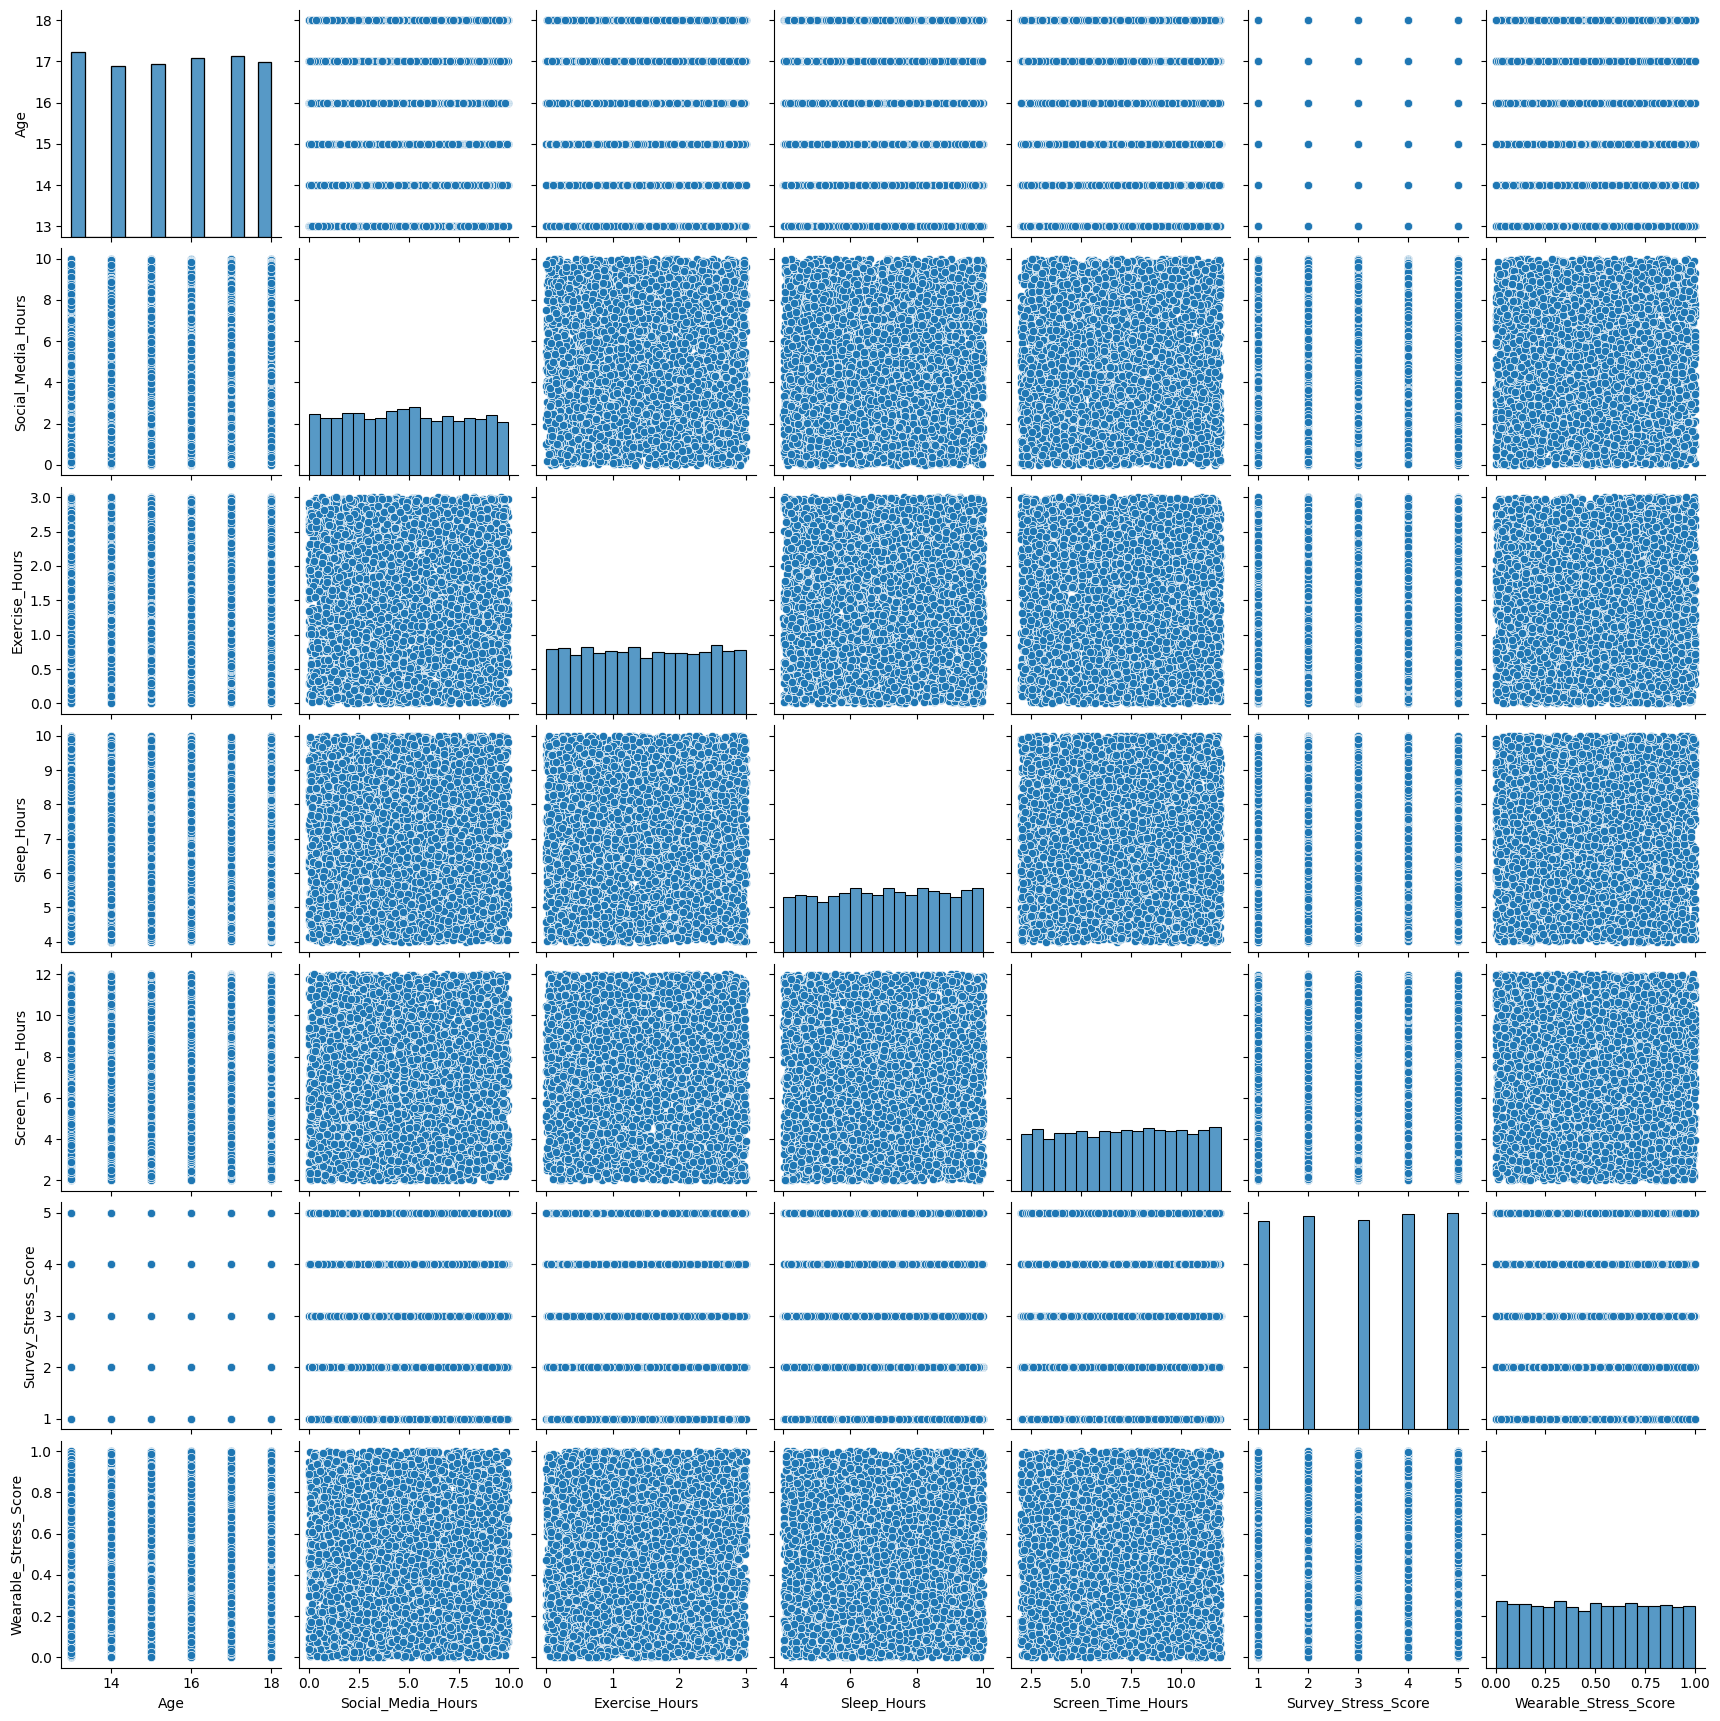

In [ ]:
# Exclude userID column
df_copy = df.copy()
df_copy = df_copy.drop('User_ID', axis=1)
sns.pairplot(df_copy)

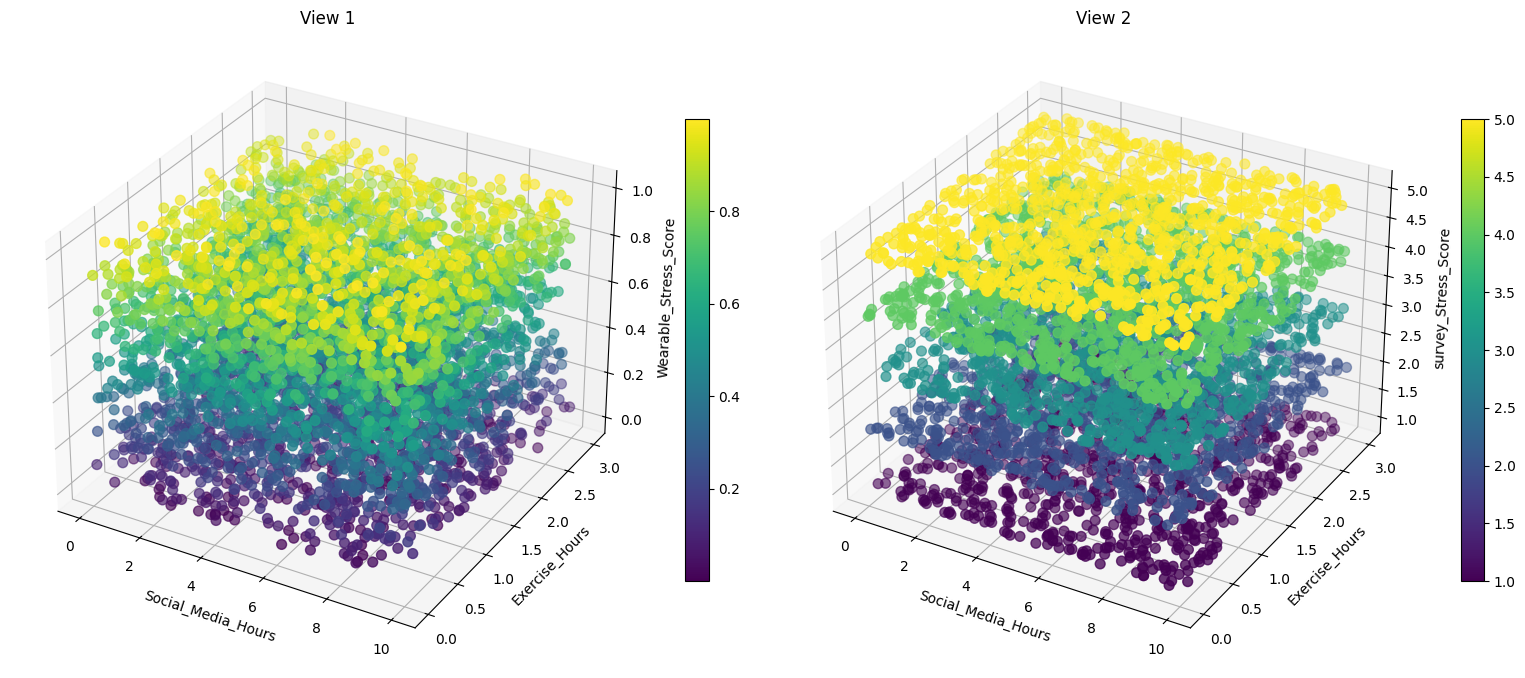

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 8),
    subplot_kw={'projection': '3d'}
)

# First graph
fg1 = ax1.scatter(
    df_copy['Social_Media_Hours'],
    df_copy['Exercise_Hours'],
    df_copy['Wearable_Stress_Score'],
    c=df_copy['Wearable_Stress_Score'],
    s=50
)

ax1.set_xlabel('Social_Media_Hours')
ax1.set_ylabel('Exercise_Hours')
ax1.set_zlabel('Wearable_Stress_Score')
ax1.set_title('View 1')

# Second graph
fg2 = ax2.scatter(
    df_copy['Social_Media_Hours'],
    df_copy['Exercise_Hours'],
    df_copy['Survey_Stress_Score'],
    c=df_copy['Survey_Stress_Score'],
    s=50
)

ax2.set_xlabel('Social_Media_Hours')
ax2.set_ylabel('Exercise_Hours')
ax2.set_zlabel('survey_Stress_Score')
ax2.set_title('View 2')

# Colorbars
fig.colorbar(fg1, ax=ax1, shrink=0.6)
fig.colorbar(fg2, ax=ax2, shrink=0.6)

plt.tight_layout()
plt.show()

<Axes: >

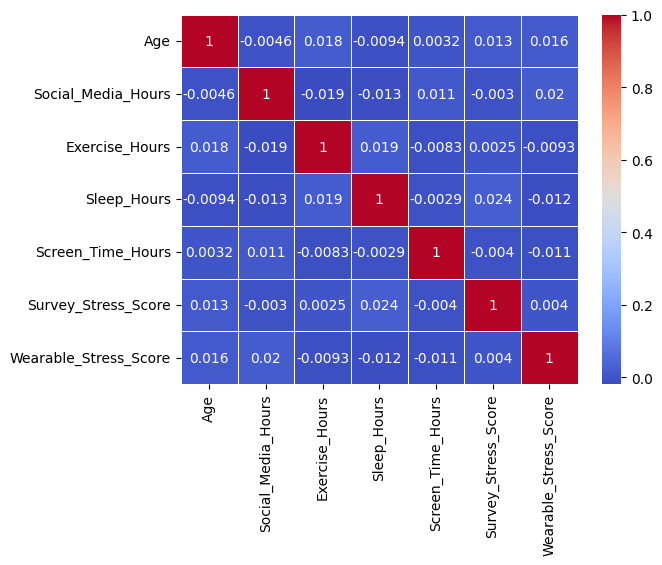

In [ ]:
sns.heatmap(df_copy.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', linewidths=0.5)

## Analysis
Availability to use regression models
* None of the present a linear relationship, so linear regression is not possible
* For the paiplot, we don't see any pattern, just a lot of points in all graph. So, a non-linear regression is not possible

Availability to use classification models
* For logistic regression, we maybe can test and see if it will generate good results

Availability to use tree models
* Let's test Decision Tree, Random Forest, XGBoost

### Candidate variables to be predicted
* Academic_Performance: It will be interesting to see the impact of each feature.
* Survey_Stress_Score has unique values in range 1-5; It will be interesting how people perseive their well being in terms of hours spent on activities.

In [ ]:
# For the categorical values
dict_uni = {}
for column in df.columns:
  if type(df[column][0]) == str:
    dict_uni[column] = np.unique_counts(df[column].nunique())
    print(dict_uni[column])

for key in dict_uni:
  print(df.groupby(key)['User_ID'].nunique())

UniqueCountsResult(values=array([2]), counts=array([1]))
UniqueCountsResult(values=array([3]), counts=array([1]))
UniqueCountsResult(values=array([4]), counts=array([1]))
Gender
F    2528
M    2472
Name: User_ID, dtype: int64
Support_System
High        1677
Low         1627
Moderate    1696
Name: User_ID, dtype: int64
Academic_Performance
Average      1234
Excellent    1202
Good         1271
Poor         1293
Name: User_ID, dtype: int64


## For demonstration purposes, I will analyze only Academic_Performance
Logistic Regression

In [ ]:
# Logistic Regression Analysis
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(export_text(Tree_class, feature_names=y, show_weights=True)) = df.drop(columns=['User_ID','Academic_Performance'])
y = df['Academic_Performance']

# tranform the categorical values in dummy values
X = pd.get_dummies(X, columns=['Gender', 'Support_System'], dtype=int)

# split the data into training and test set (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# normalize the data (without data normalization the model not converge)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# training the model on the training set
lgr = LogisticRegression()
lgr.fit(X_train, y_train)

# test the model on the test set
y_pred = lgr.predict(X_test)

# evaluate the model results
print('Accuracy of the model: %.2f' % accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_pred, y_test))


Accuracy of the model: 0.23
              precision    recall  f1-score   support

     Average       0.19      0.08      0.12       356
   Excellent       0.23      0.17      0.20       382
        Good       0.24      0.30      0.26       378
        Poor       0.24      0.37      0.29       384

    accuracy                           0.23      1500
   macro avg       0.23      0.23      0.22      1500
weighted avg       0.23      0.23      0.22      1500

[[ 30  38  51  36]
 [ 69  66  71  78]
 [111 125 112 127]
 [146 153 144 143]]


Decission Tree Class

In [ ]:
# Decision Tree Class Analysis
import sklearn.model_selection as skm
from sklearn.tree import (DecisionTreeClassifier as DTC ,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss

Tree_class = DTC(criterion='entropy', max_depth =3, random_state =1)
Tree_class.fit(X_train , y_train)

# test the model on the test set
y_pred_tree = Tree_class.predict(X_test)

# evaluate the model results
print('Accuracy of the model: %.2f' % accuracy_score(y_test, y_pred_tree))

resid_dev = np.sum(log_loss(y_train, Tree_class.predict_proba(X_train)))
print(resid_dev)

Accuracy of the model: 0.24
1.3724658851642282


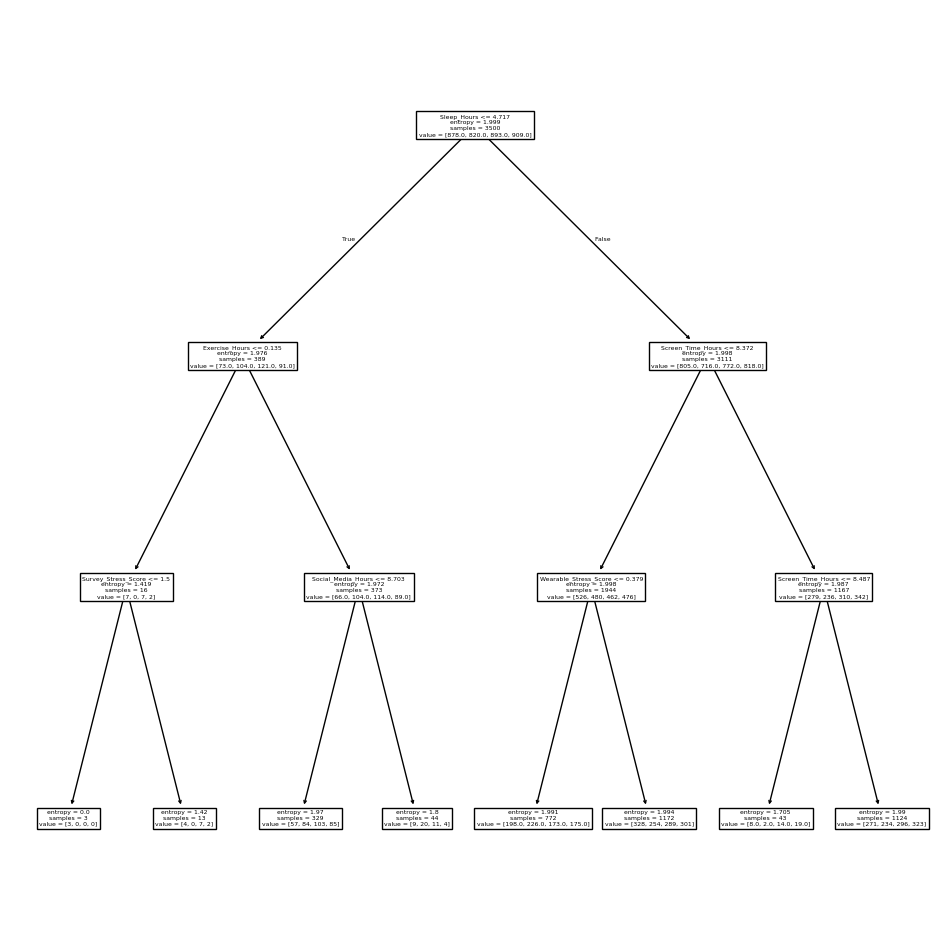

In [ ]:
ax = plt.subplots(figsize =(12 ,12))[1]
plot_tree(Tree_class, feature_names=list(X.columns), ax=ax);
plt.show()

In [ ]:
print(export_text(Tree_class, feature_names=list(X.columns), show_weights=True))

|--- Sleep_Hours <= -1.37
|   |--- Exercise_Hours <= -1.55
|   |   |--- Wearable_Stress_Score <= 0.88
|   |   |   |--- weights: [7.00, 0.00, 4.00, 2.00] class: Average
|   |   |--- Wearable_Stress_Score >  0.88
|   |   |   |--- weights: [0.00, 0.00, 3.00, 0.00] class: Good
|   |--- Exercise_Hours >  -1.55
|   |   |--- Social_Media_Hours <= 1.32
|   |   |   |--- weights: [57.00, 84.00, 103.00, 85.00] class: Good
|   |   |--- Social_Media_Hours >  1.32
|   |   |   |--- weights: [9.00, 20.00, 11.00, 4.00] class: Excellent
|--- Sleep_Hours >  -1.37
|   |--- Screen_Time_Hours <= 0.44
|   |   |--- Wearable_Stress_Score <= -0.39
|   |   |   |--- weights: [198.00, 226.00, 173.00, 175.00] class: Excellent
|   |   |--- Wearable_Stress_Score >  -0.39
|   |   |   |--- weights: [328.00, 254.00, 289.00, 301.00] class: Average
|   |--- Screen_Time_Hours >  0.44
|   |   |--- Screen_Time_Hours <= 0.48
|   |   |   |--- weights: [8.00, 2.00, 14.00, 19.00] class: Poor
|   |   |--- Screen_Time_Hours >  0.4

Random Forest


In [ ]:
# Random Forest Analysis
from sklearn.ensemble import RandomForestClassifier as RF

rf = RF(max_features=X_train.shape[1], random_state =1)
rf.fit(X_train , y_train)

# test the model on the test set
y_pred_rf = rf.predict(X_test)

# evaluate the model results
print('Accuracy of the model: %.2f' % accuracy_score(y_test, y_pred_rf))
print("MSE", np.mean((y_test - y_pred_rf)**2))


Accuracy of the model: 0.25
MSE 2.488


In [ ]:
feature_imp = pd.DataFrame({'importance':rf.feature_importances_}, index=list(X.columns))
feature_imp_sorted = feature_imp.sort_values('importance', ascending=False)
print(feature_imp_sorted)

                         importance
Screen_Time_Hours          0.162600
Wearable_Stress_Score      0.158629
Exercise_Hours             0.158285
Social_Media_Hours         0.158206
Sleep_Hours                0.156600
Age                        0.066118
Survey_Stress_Score        0.059459
Support_System_Moderate    0.018923
Support_System_High        0.018328
Support_System_Low         0.016625
Gender_M                   0.013307
Gender_F                   0.012922


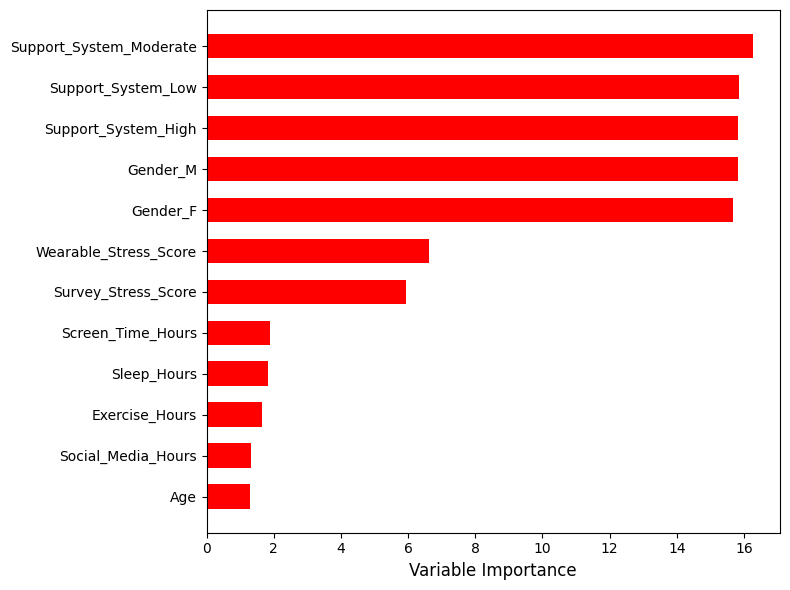

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(feature_imp.index, feature_imp.sort_values('importance')['importance'] * 100, color='red', height=0.6)
plt.xlabel('Variable Importance', fontsize=12)
plt.tight_layout()
plt.show()

Decission Tree Reg


In [ ]:
# Decision Tree Regress Analysis

# y target value encoded
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# split the data into training and test set (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=1)

Tree_reg = DTR(max_depth=3)
Tree_reg.fit(X_train , y_train)

DecisionTreeRegressor(max_depth=3)

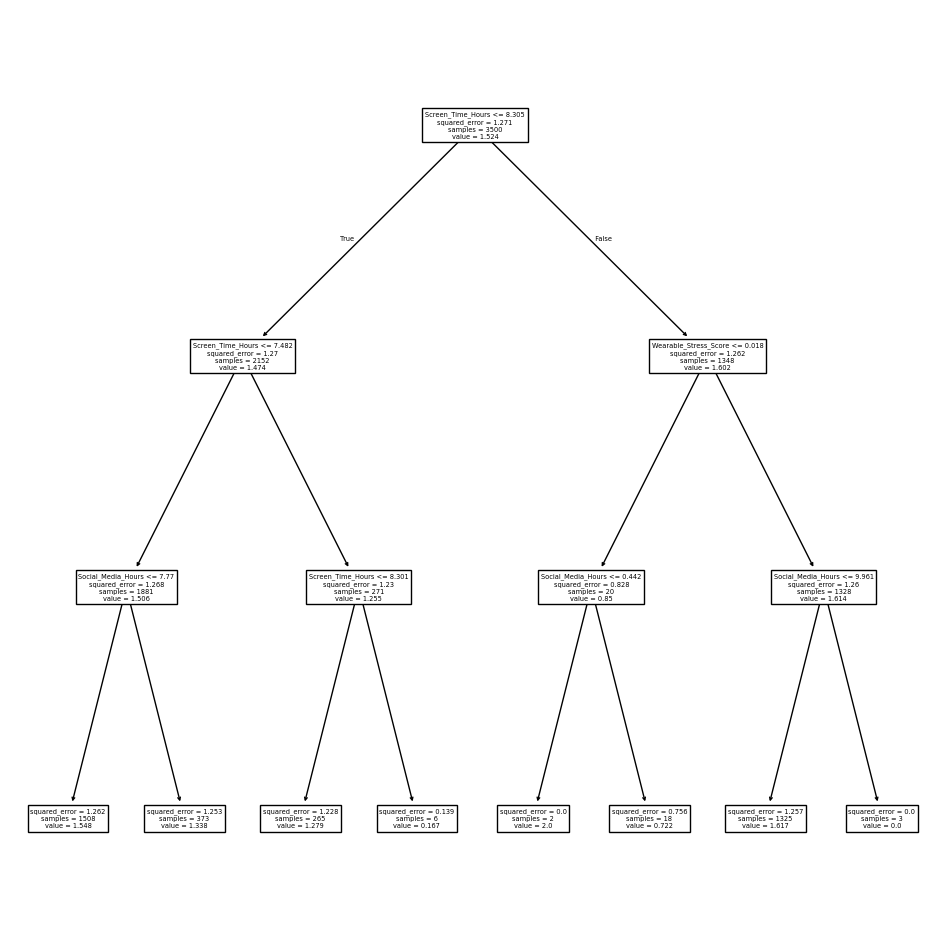

In [ ]:
ax = plt.subplots(figsize =(12 ,12))[1]
plot_tree(Tree_reg,feature_names=list(X.columns), ax=ax);
plt.show()
plt.close()

In [ ]:
# Prune Tree
ccp_path = Tree_reg.cost_complexity_pruning_path (X_train, y_train)
kfold = skm.KFold(5, shuffle=True, random_state =10)
grid = skm.GridSearchCV(Tree_reg , {'ccp_alpha': ccp_path.ccp_alphas},
refit=True, cv=kfold, scoring='neg_mean_squared_error')
G = grid.fit(X_train, y_train)

best_ = grid.best_estimator_
print(np.mean(( y_test - best_.predict(X_test))**2))

1.25128398617464


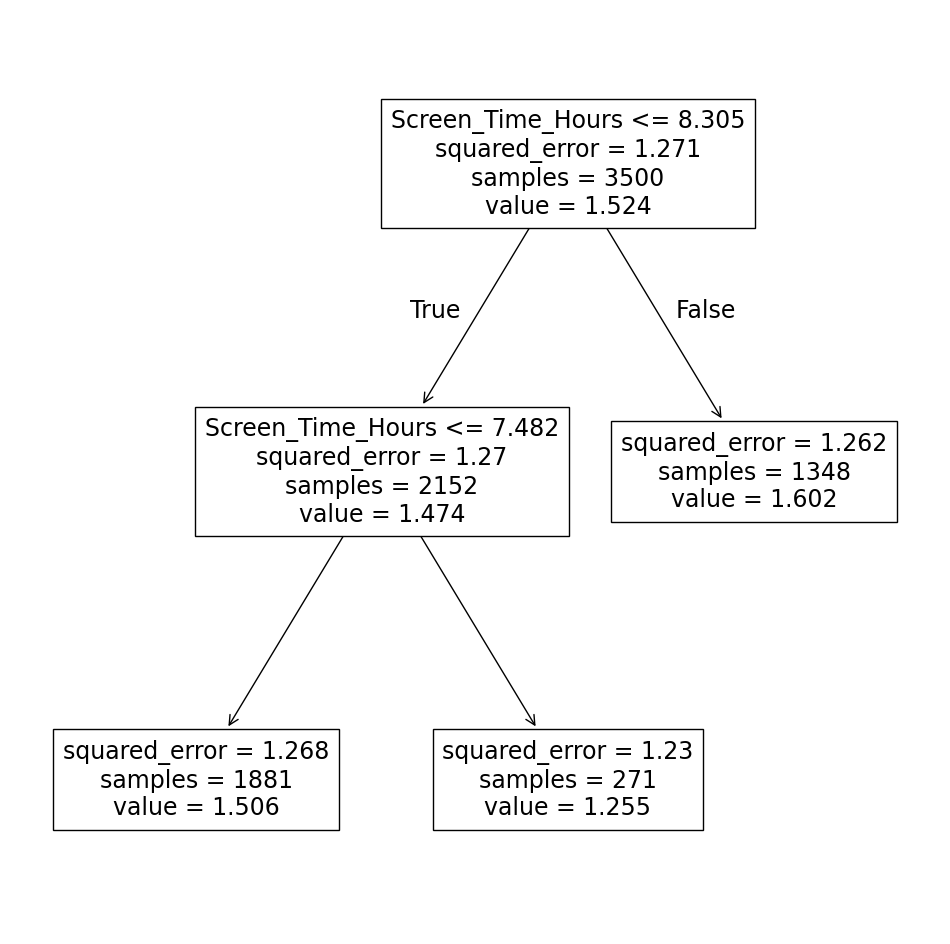

In [ ]:
ax = plt.subplots(figsize =(12 ,12))[1]
plot_tree(G.best_estimator_, feature_names=list(X.columns), ax=ax);
plt.show()

XGBoost

In [ ]:
# XGBoost Analysis

from xgboost import XGBClassifier as XGBC

xgb = XGBC(max_depth =3, learning_rate=1, objective='binary:logistic', random_state =1)
xgb.fit(X_train , y_train)

# test the model on the test set
y_pred_xgb = xgb.predict(X_test)

# evaluate the model results
print('Accuracy of the model: %.2f' % accuracy_score(y_test, y_pred_xgb))

Accuracy of the model: 0.27


In [ ]:
feature_imp = pd.DataFrame({'importance':xgb.feature_importances_}, index=list(X.columns))
feature_imp_sorted = feature_imp.sort_values('importance', ascending=False)
print(feature_imp_sorted)

                         importance
Support_System_Moderate    0.120788
Age                        0.096229
Survey_Stress_Score        0.092061
Wearable_Stress_Score      0.090458
Support_System_Low         0.090414
Social_Media_Hours         0.089641
Sleep_Hours                0.085923
Support_System_High        0.085368
Gender_F                   0.083391
Exercise_Hours             0.083195
Screen_Time_Hours          0.082532
Gender_M                   0.000000


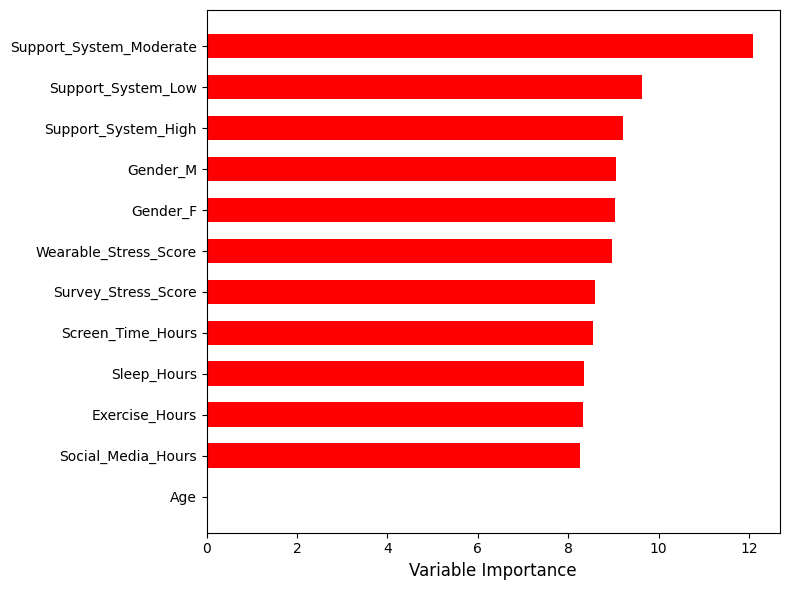

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(feature_imp.index, feature_imp.sort_values('importance')['importance'] * 100, color='red', height=0.6)
plt.xlabel('Variable Importance', fontsize=12)
plt.tight_layout()
plt.show()